# Use case 7: regions of interest in DTE data, notified by Aviso, retrieved with Polytope

A DestinE user cares about a few **regions of interest**, not the globe. This notebook shows the
consumer side of that workflow with **Aviso 2** and **Polytope**:

1. define regions (polygon, bounding box, point) and pick one from a drop-down menu;
2. subscribe **spatially** on the Aviso playground, so only notifications whose footprint
   intersects the region are delivered (`de-scm-data-points` with a subscriber polygon,
   `extreme_event` with a polygon or a point plus value constraints);
3. on a notification, pull **only the region's data** from the Extremes-DT via Polytope
   **feature extraction** (time series at a point, polygon / bounding-box cut-outs) and plot it.

| Setting | Value |
| --- | --- |
| Aviso server | `https://aviso-playground.ecmwf.int` (Aviso 2 playground; override with `AVISO_BASE_URL`) |
| Spatial event types | `de-scm-data-points` (publisher `point_cloud`, subscriber `polygon` list), `extreme_event` (`polygon` string or `point`, `severity` constraints) |
| Aviso auth | ECMWF token from `AVISO_TOKEN` or `~/.config/aviso/config.yaml` (`auth.bearer_token`) |
| Data | Polytope at `polytope.lumi.apps.dte.destination-earth.eu`, dataset `extremes-dt`, DESP offline token in `~/.polytopeapirc` |
| Client | `pip install pyaviso earthkit-data earthkit-plots ipywidgets cartopy pyyaml pandas` |

> The production DestinE stream (`data` on `aviso2.lumi.apps.dte.destination-earth.eu`) carries
> MARS-like identifiers and **no spatial field**, so today a region filter on it is done on the
> data side (section 5). The playground streams show what a spatially indexed DestinE stream
> gives you: the server drops everything outside your polygon before it reaches you.

Sections: 1 Setup · 2 Regions of interest · 3 Spatial subscriptions · 4 Live test (one test
publish, two regions) · 5 Polytope feature extraction for the region · 6 The whole pipeline ·
7 On-demand Extremes-DT (DEODE) datacube · 8 Notes, quotas and related Polytope examples

## 1. Setup and authentication

`AVISO_TOKEN` wins; otherwise the token in the aviso CLI config file is used. Polytope reads its own
DESP offline token from `~/.polytopeapirc` (created by `desp-authentication.py`). No token is printed.

In [1]:
# Uncomment to install into the active kernel:
# %pip install -q pyaviso earthkit-data earthkit-plots ipywidgets cartopy pyyaml pandas

import json
import os
import pathlib
import queue
import threading
import time
from datetime import datetime, timedelta, timezone

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyaviso
import earthkit.data as ekd
from IPython.display import display

print("pyaviso", pyaviso.__version__, "| earthkit-data", ekd.__version__)

pyaviso 2.1.0 | earthkit-data 1.1.0


In [2]:
BASE_URL = os.environ.get("AVISO_BASE_URL", "https://aviso-playground.ecmwf.int").rstrip("/")
POINTS_EVENT = "de-scm-data-points"
EXTREME_EVENT = "extreme_event"
POLYTOPE_ADDRESS = "polytope.lumi.apps.dte.destination-earth.eu"
DATASET = "extremes-dt"
CLI_CONFIG = pathlib.Path.home() / ".config" / "aviso" / "config.yaml"
POLYTOPE_RC = pathlib.Path.home() / ".polytopeapirc"
OUT_DIR = pathlib.Path("output") / "uc07"
OUT_DIR.mkdir(parents=True, exist_ok=True)


def resolve_token():
    token = os.environ.get("AVISO_TOKEN")
    if token:
        return token
    if CLI_CONFIG.exists():
        import yaml
        cfg = yaml.safe_load(CLI_CONFIG.read_text(encoding="utf-8")) or {}
        token = (cfg.get("auth") or {}).get("bearer_token")
        if token:
            return token
    raise RuntimeError(f"No aviso token: set AVISO_TOKEN or auth.bearer_token in {CLI_CONFIG} "
                       "(token from https://api.ecmwf.int/v1/key/)")


def open_stream(client, event_type, *, filter, start=None, mode=None):
    # pyaviso 2.1.0 names the cursor `start_from=`; newer builds `from_=`.
    kwargs = {"filter": filter}
    if mode is not None:
        kwargs["mode"] = mode
    if start is None:
        return client.listen(event_type, **kwargs)
    try:
        return client.listen(event_type, start_from=start, **kwargs)
    except TypeError:
        return client.listen(event_type, from_=start, **kwargs)


token = resolve_token()
client = pyaviso.AvisoClient(base_url=BASE_URL, auth=pyaviso.Bearer(token))
print("aviso:", client.base_url, "| token loaded")
print("polytope credentials:", "found" if POLYTOPE_RC.exists() else f"MISSING ({POLYTOPE_RC}) - run DE/aviso-examples/desp-authentication.py")

aviso: https://aviso-playground.ecmwf.int/ | token loaded
polytope credentials: found


## 2. Regions of interest

Each region has a **closed polygon** (`[[lat, lon], ...]`, first point repeated), a **bounding
box** `[N, W, S, E]` and a **reference point**. The polygon is what Aviso matches against; the box
and point drive the Polytope requests. Add your own regions to the dictionary.

Dropdown(description='region', options=('Lisbon', 'Alps', 'North Sea', 'Po valley', 'Bergen'), value='Lisbon')

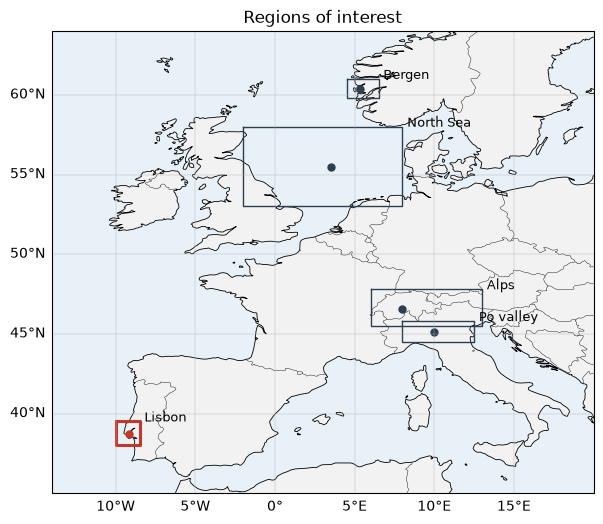

In [3]:
def box_polygon(n, w, s, e):
    return [[n, w], [n, e], [s, e], [s, w], [n, w]]


# bbox = [N, W, S, E]; point = land reference point; sea_point = nearest open-sea point (for the wave model)
REGIONS = {
    "Lisbon":     {"bbox": [39.5, -10.0, 38.0, -8.5], "point": [38.72, -9.15], "sea_point": [38.6, -9.9]},
    "Alps":       {"bbox": [47.8, 6.0, 45.5, 13.0],   "point": [46.55, 8.0],   "sea_point": [43.8, 8.5]},
    "North Sea":  {"bbox": [58.0, -2.0, 53.0, 8.0],    "point": [55.5, 3.5],    "sea_point": [55.5, 3.5]},
    "Po valley":  {"bbox": [45.8, 8.0, 44.5, 12.5],    "point": [45.1, 10.0],   "sea_point": [44.6, 12.9]},
    "Bergen":     {"bbox": [61.0, 4.5, 59.8, 6.5],     "point": [60.39, 5.32],  "sea_point": [60.4, 4.0]},
}
for r in REGIONS.values():
    r["polygon"] = box_polygon(*r["bbox"])

w_region = widgets.Dropdown(options=list(REGIONS), value="Lisbon", description="region")
display(w_region)


def region():
    return w_region.value, REGIONS[w_region.value]


def plot_regions(highlight=None, extra_points=None, title="Regions of interest"):
    fig = plt.figure(figsize=(8, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-14, 20, 35, 64], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="#f2f2f2")
    ax.add_feature(cfeature.OCEAN, facecolor="#e8f1f8")
    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    for name, r in REGIONS.items():
        lats, lons = zip(*r["polygon"])
        sel = name == highlight
        ax.plot(lons, lats, color="#c0392b" if sel else "#2c3e50", lw=2.2 if sel else 1.0, transform=ccrs.PlateCarree())
        ax.plot(r["point"][1], r["point"][0], "o", ms=5, color="#c0392b" if sel else "#2c3e50", transform=ccrs.PlateCarree())
        ax.text(r["bbox"][3] + 0.3, r["bbox"][0], name, fontsize=9, transform=ccrs.PlateCarree())
    if extra_points:
        pts = np.array(extra_points)
        ax.scatter(pts[:, 1], pts[:, 0], s=10, color="#2980b9", zorder=5, transform=ccrs.PlateCarree(), label="notification point cloud")
        ax.legend(loc="lower left")
    ax.gridlines(draw_labels={"bottom": "x", "left": "y"}, linewidth=0.3)
    ax.set_title(title)
    plt.show()


plot_regions(highlight=w_region.value)

## 3. Spatial subscriptions

The two playground streams use two encodings, both taken from the live schema:

| Stream | Publisher sends | Subscriber sends | Match rule |
| --- | --- | --- | --- |
| `de-scm-data-points` | `point_cloud`: `[[lat, lon], ...]` (max 10 000 points) | `polygon`: closed list of `[lat, lon]` (never `point_cloud`) | delivered if any point falls inside the polygon |
| `extreme_event` | `polygon`: string `"(lat,lon,lat,lon,...)"`, closed | `polygon` string **or** `point: "lat,lon"`; scalar fields accept `{"gte": 5}` style constraints | polygons intersect / polygon contains point |

`experiment`, `region`, `run_time`, `severity` are required in a filter; `"*"` is the wildcard for
string fields (`experiment`), constraints (`{"gte": 1}`) are the wildcard for numeric ones.

In [4]:
for name in (POINTS_EVENT, EXTREME_EVENT):
    spec = client.schema_for(name).schema["identifier"]
    print(f"=== {name} ===")
    for key, s in spec.items():
        print(f"  {key:<12} {s.get('type'):<18} required={s.get('required', False)!s:<5} {s.get('description', '') or s.get('values', '')}")

=== de-scm-data-points ===
  date         DateHandler        required=False 
  experiment   StringHandler      required=True  
  point_cloud  PointCloudHandler  required=True  Publishers provide point_cloud as [[latitude, longitude], ...]. Watch and replay requests provide a closed polygon instead. The polygon satisfies this required field; subscribers must not send point_cloud.
  time         TimeHandler        required=False 
=== extreme_event ===
  anomaly      FloatHandler       required=False 
  polygon      PolygonHandler     required=True  
  region       EnumHandler        required=True  Geographic region label.
  run_time     TimeHandler        required=True  
  severity     IntHandler         required=True  Severity level from 1 to 7.


In [5]:
def polygon_string(polygon):
    # extreme_event wants "(lat,lon,lat,lon,...)"; de-scm-data-points wants the list form.
    return "(" + ",".join(f"{lat},{lon}" for lat, lon in polygon) + ")"


def points_filter(reg, experiment="*"):
    return {"experiment": experiment, "polygon": reg["polygon"]}


def extreme_filter(reg, use_point=False, min_severity=1, region_label="north", run_time="1200"):
    f = {"region": region_label, "run_time": run_time, "severity": {"gte": min_severity}}
    if use_point:
        f["point"] = f"{reg['point'][0]},{reg['point'][1]}"
    else:
        f["polygon"] = polygon_string(reg["polygon"])
    return f


def replay(client, event_type, *, filter, start=1):
    with open_stream(client, event_type, filter=filter, start=start, mode="replay_only") as stream:
        return list(stream)


def to_frame(notifications):
    rows = []
    for n in notifications:
        ce = n.cloudevent or {}
        row = {"sequence": n.sequence, "published_utc": ce.get("time"), "event_type": n.event_type}
        for k, v in n.identifier.items():
            row[k] = f"<{len(v)} points>" if k == "point_cloud" and isinstance(v, list) else v
        row["payload"] = n.payload
        rows.append(row)
    return pd.DataFrame(rows)


name, reg = region()
print("region:", name)
print("de-scm-data-points filter:", json.dumps(points_filter(reg)))
print("extreme_event filter     :", json.dumps(extreme_filter(reg)))
print("extreme_event point form :", json.dumps(extreme_filter(reg, use_point=True)))

region: Lisbon
de-scm-data-points filter: {"experiment": "*", "polygon": [[39.5, -10.0], [39.5, -8.5], [38.0, -8.5], [38.0, -10.0], [39.5, -10.0]]}
extreme_event filter     : {"region": "north", "run_time": "1200", "severity": {"gte": 1}, "polygon": "(39.5,-10.0,39.5,-8.5,38.0,-8.5,38.0,-10.0,39.5,-10.0)"}
extreme_event point form : {"region": "north", "run_time": "1200", "severity": {"gte": 1}, "point": "38.72,-9.15"}


In [6]:
# Replay the retained history that intersects the region (sequence 1 = everything still retained).
hist_points = replay(client, POINTS_EVENT, filter=points_filter(reg))
hist_extreme = replay(client, EXTREME_EVENT, filter=extreme_filter(reg))
print(f"{name}: {len(hist_points)} retained {POINTS_EVENT} and {len(hist_extreme)} retained {EXTREME_EVENT} notification(s) intersect the region")
display(to_frame(hist_points + hist_extreme).tail(8))

Lisbon: 9 retained de-scm-data-points and 0 retained extreme_event notification(s) intersect the region


,sequence,published_utc,event_type,date,experiment,point_cloud,time,payload
1,18,2026-09-24T15:38:22.049770266Z,de-scm-data-points,20260924,roitest,<4 points>,1538,"{'note': 'roi-uc7-notebook-test', 'region': 'L..."
2,19,2026-09-24T15:39:43.074382449Z,de-scm-data-points,20260924,roitest,<4 points>,1539,"{'note': 'roi-uc7-notebook-test', 'region': 'L..."
3,20,2026-09-24T15:45:35.806219732Z,de-scm-data-points,20250926,gcgkrb,<54 points>,0000,"{'bbox': {'E': -5.5, 'N': 43.0, 'S': 36.0, 'W'..."
4,21,2026-09-24T15:45:37.480795676Z,de-scm-data-points,20250926,gcgkrb,<54 points>,0000,"{'bbox': {'E': -5.5, 'N': 43.0, 'S': 36.0, 'W'..."
5,22,2026-09-24T15:45:39.124271673Z,de-scm-data-points,20250926,gcgkrb,<54 points>,0000,"{'bbox': {'E': -5.5, 'N': 43.0, 'S': 36.0, 'W'..."
6,23,2026-09-24T15:47:21.307425478Z,de-scm-data-points,20260924,roitest,<4 points>,1547,"{'note': 'roi-uc7-notebook-test', 'region': 'L..."
7,24,2026-09-24T15:48:41.083100558Z,de-scm-data-points,20260924,roitest,<4 points>,1548,"{'note': 'roi-uc7-notebook-test', 'region': 'L..."
8,25,2026-09-24T15:50:03.525626495Z,de-scm-data-points,20260924,roitest,<4 points>,1550,"{'note': 'roi-uc7-notebook-test', 'region': 'L..."


## 4. Live test: one publish, two regions

`listen_many` opens one live watch per region in worker threads and collects what each receives
for a bounded time (the cell always returns). One **clearly marked test notification** is
published on the playground while the watches are open: a small point cloud inside the selected
region, experiment `roitest`, payload `roi-uc7-notebook-test`. The selected region receives it;
a region that does not overlap stays silent, which is the whole point of a spatial subscription.

`PUBLISH_TEST = False` turns the publish off (the watches then simply wait for real traffic).

[  1.5s] Lisbon       seq=26 experiment=roitest points=4 payload={'note': 'roi-uc7-notebook-test', 'region': 'Lisbon'}  published test notification: success request_id=433edfdf-6f90-42b3-bc48-e68264495682



watches closed after 15.2s: {'Lisbon': 1, 'Alps': 0}


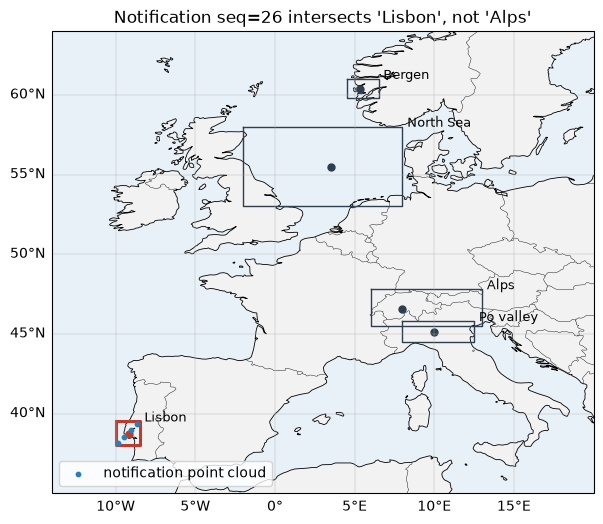

In [7]:
def listen_many(client, event_type, filters, *, seconds=15, publisher=None, delay=1.5):
    # filters: {label: filter}. Returns {label: [notifications]}.
    streams = {label: open_stream(client, event_type, filter=f) for label, f in filters.items()}
    q = queue.Queue()

    def pump(label, stream):
        try:
            for n in stream:
                q.put((label, n))
        except Exception as exc:
            q.put((label, exc))

    workers = [threading.Thread(target=pump, args=(label, s), daemon=True) for label, s in streams.items()]
    for w in workers:
        w.start()
    if publisher:
        threading.Timer(delay, publisher).start()
    received = {label: [] for label in filters}
    t0, deadline = time.monotonic(), time.monotonic() + seconds
    while time.monotonic() < deadline:
        try:
            label, item = q.get(timeout=min(1.0, max(deadline - time.monotonic(), 0.05)))
        except queue.Empty:
            continue
        if isinstance(item, Exception):
            print(f"[{label}] stream error: {type(item).__name__}: {item}")
            continue
        received[label].append(item)
        print(f"[{time.monotonic() - t0:5.1f}s] {label:<12} seq={item.sequence} experiment={item.identifier.get('experiment')} "
              f"points={len(item.identifier.get('point_cloud') or [])} payload={item.payload}")
    for s in streams.values():
        s.close()
    for w in workers:
        w.join(timeout=3)
    print(f"watches closed after {time.monotonic() - t0:.1f}s:", {k: len(v) for k, v in received.items()})
    return received


def point_cloud_for(reg, n=4):
    # A few points inside the region's box: what a producer would attach to its notification.
    N, W, S, E = reg["bbox"]
    lats = np.linspace(S + 0.1 * (N - S), N - 0.1 * (N - S), n)
    lons = np.linspace(W + 0.1 * (E - W), E - 0.1 * (E - W), n)
    return [[round(float(la), 3), round(float(lo), 3)] for la, lo in zip(lats, lons)]


PUBLISH_TEST = True          # playground only; never point this at a production server
TEST_EXPERIMENT = "roitest"

name, reg = region()
other = next(k for k in REGIONS if k != name)
test_cloud = point_cloud_for(reg)
now = datetime.now(timezone.utc)


def publish_test():
    resp = client.notify(
        event_type=POINTS_EVENT,
        identifier={"experiment": TEST_EXPERIMENT, "date": now.strftime("%Y%m%d"), "time": now.strftime("%H%M"),
                    "point_cloud": test_cloud},
        payload={"note": "roi-uc7-notebook-test", "region": name},
    )
    print(f"  published test notification: {resp.status} request_id={resp.request_id}")


received = listen_many(
    client, POINTS_EVENT,
    {name: points_filter(reg, TEST_EXPERIMENT), other: points_filter(REGIONS[other], TEST_EXPERIMENT)},
    seconds=15, publisher=publish_test if PUBLISH_TEST else None,
)
event = received[name][-1] if received[name] else None
if event is not None:
    plot_regions(highlight=name, extra_points=event.identifier.get("point_cloud"),
                 title=f"Notification seq={event.sequence} intersects '{name}', not '{other}'")

## 5. Polytope feature extraction for the region

A notification says *which* forecast exists; the region says *where* you care. Polytope's
**feature extraction** cuts the Extremes-DT field down on the data bridge before transfer, so
the answer is kilobytes instead of a 50 MB global GRIB. The request shapes below are the
canonical ones from the `polytope-examples` repository (`extremes-dt/feature-extraction/`),
filled with the region's polygon, bounding box and points:

| Feature | `feature` fragment | Other keys | Returns |
| --- | --- | --- | --- |
| `timeseries` | `{"type": "timeseries", "points": [[lat, lon]], "axes": "step", "range": {"start": 0, "end": 48}}` | `param: "165/167"` (multi-param) | one value per step and parameter |
| `boundingbox` | `{"type": "boundingbox", "points": [[N, W], [S, E]], "axes": ["latitude", "longitude"]}` | `step: "12"` | grid points inside the box |
| `polygon` | `{"type": "polygon", "shape": [[lat, lon], ...], "axes": ["latitude", "longitude"]}` | `param: "165/167"`, `step: "12"` | grid points inside the polygon |
| `verticalprofile` | `{"type": "verticalprofile", "points": [[lat, lon]], "range": {"start": "0", "end": "1000"}}` | `levtype: "pl"`, `param: "131"`, `step: "0"` | one value per pressure level |
| `trajectory` | `{"type": "trajectory", "points": [[lat, lon], ...], "inflation": 0.1, "inflate": "round", "axes": ["latitude", "longitude"]}` | `step: "0"` | grid points within 0.1° of the track |
| `wave-timeseries` | `{"type": "timeseries", "points": [[lat, lon]], "time_axis": "step"}` | `stream: "wave"`, `param: "140232"`, `step: "0/to/20"` | mean wave period per step at a sea point |

Dates can be relative (`"date": "-2"` = two days ago, the examples use `"-14"`); here the
notification's forecast date is used when it is inside the Polytope window, otherwise `"-2"`.

**Requests per run.** Only the **selected** feature and the `timeseries` are executed live
(twice: once here, once in the pipeline of section 6), so a run makes at most 4 Polytope calls.
The other shapes are printed as code. `LIVE_REQUEST` (env var or the flag below) switches to the
cached CoverageJSON files under `output/uc07/`, exactly as in the `polytope-examples` notebooks.

In [8]:
# Defaults to making live data requests. Set LIVE_REQUEST=false (env) or edit here to reuse the cached CoverageJSON files.
LIVE_REQUEST = os.getenv("LIVE_REQUEST", "true").lower() == "true"

w_feature = widgets.Dropdown(options=["polygon", "boundingbox", "timeseries", "verticalprofile", "trajectory", "wave-timeseries"],
                             value="polygon", description="feature")
w_param = widgets.Dropdown(options={"2t: 2 metre temperature": "167", "10u/2t (multi-param)": "165/167", "10u: 10 m U wind": "165",
                                    "msl: mean sea level pressure": "151", "tp: total precipitation": "228"},
                           value="165/167", description="param")
w_step = widgets.Dropdown(options=["0", "1", "6", "12", "18", "24", "36", "48"], value="12", description="cut-out step")
display(widgets.HBox([w_feature, w_param, w_step]))
print("LIVE_REQUEST =", LIVE_REQUEST)


def date_for(notification=None):
    # Forecast base date from the notification if it is a complete run inside the Polytope window, else relative "-2".
    yesterday = (datetime.now(timezone.utc) - timedelta(days=1)).strftime("%Y%m%d")
    floor = (datetime.now(timezone.utc) - timedelta(days=13)).strftime("%Y%m%d")
    d = str((notification.identifier if notification else {}).get("date") or "")
    return d if len(d) == 8 and floor <= d <= yesterday else "-2"


def base_request(notification=None):
    return {"dataset": DATASET, "class": "d1", "stream": "oper", "type": "fc", "date": date_for(notification),
            "time": "0000", "levtype": "sfc", "expver": "0001"}


def transect(reg, n=12):
    # A straight track through the region (SW corner to NE corner) as a trajectory example.
    N, W, S, E = reg["bbox"]
    return [[round(float(la), 3), round(float(lo), 3)] for la, lo in zip(np.linspace(S, N, n), np.linspace(W, E, n))]


def feature_request(kind, reg, notification=None, param=None, step=None):
    # Exactly the shapes of polytope-examples/extremes-dt/feature-extraction/*.ipynb, with region geometry filled in.
    N, W, S, E = reg["bbox"]
    param = param or w_param.value
    step = str(step or w_step.value)
    req = base_request(notification)
    if kind == "timeseries":
        req.update({"param": param,
                    "feature": {"type": "timeseries", "points": [reg["point"]], "axes": "step", "range": {"start": 0, "end": 48}}})
    elif kind == "boundingbox":
        req.update({"param": param.split("/")[-1], "step": step,
                    "feature": {"type": "boundingbox", "points": [[N, W], [S, E]], "axes": ["latitude", "longitude"]}})
    elif kind == "polygon":
        req.update({"param": param, "step": step,
                    "feature": {"type": "polygon", "shape": reg["polygon"], "axes": ["latitude", "longitude"]}})
    elif kind == "verticalprofile":
        req.update({"levtype": "pl", "param": "131", "step": "0",
                    "feature": {"type": "verticalprofile", "points": [reg["point"]], "range": {"start": "0", "end": "1000"}}})
    elif kind == "trajectory":
        req.update({"param": param.split("/")[-1], "step": "0",
                    "feature": {"type": "trajectory", "points": transect(reg), "inflation": 0.1, "inflate": "round",
                                "axes": ["latitude", "longitude"]}})
    elif kind == "wave-timeseries":
        req.update({"stream": "wave", "param": "140232", "step": "0/to/20",
                    "feature": {"type": "timeseries", "points": [reg["sea_point"]], "time_axis": "step"}})
    else:
        raise ValueError(kind)
    return req


name, reg = region()
for kind in w_feature.options:
    print(f"# --- {kind} for '{name}' ---")
    print(json.dumps(feature_request(kind, reg, event), indent=None)[:400], "\n")

LIVE_REQUEST = True
# --- polygon for 'Lisbon' ---
{"dataset": "extremes-dt", "class": "d1", "stream": "oper", "type": "fc", "date": "-2", "time": "0000", "levtype": "sfc", "expver": "0001", "param": "165/167", "step": "12", "feature": {"type": "polygon", "shape": [[39.5, -10.0], [39.5, -8.5], [38.0, -8.5], [38.0, -10.0], [39.5, -10.0]], "axes": ["latitude", "longitude"]}} 

# --- boundingbox for 'Lisbon' ---
{"dataset": "extremes-dt", "class": "d1", "stream": "oper", "type": "fc", "date": "-2", "time": "0000", "levtype": "sfc", "expver": "0001", "param": "167", "step": "12", "feature": {"type": "boundingbox", "points": [[39.5, -10.0], [38.0, -8.5]], "axes": ["latitude", "longitude"]}} 

# --- timeseries for 'Lisbon' ---
{"dataset": "extremes-dt", "class": "d1", "stream": "oper", "type": "fc", "date": "-2", "time": "0000", "levtype": "sfc", "expver": "0001", "param": "165/167", "feature": {"type": "timeseries", "points": [[38.72, -9.15]], "axes": "step", "range": {"start": 0, "end": 48

In [9]:
import shutil


def fetch(request, cache_name):
    # LIVE_REQUEST/cached pattern of the polytope-examples notebooks. earthkit-data 1.1 cannot write CoverageJSON with
    # `data.to_target("file", ...)` (TypeError: bytes-like object required), so the downloaded file is copied instead.
    data_file = OUT_DIR / f"{cache_name}.covjson"
    if LIVE_REQUEST:
        t0 = time.monotonic()
        data = ekd.from_source("polytope", "destination-earth", request, address=POLYTOPE_ADDRESS, stream=False)
        try:
            data.to_target("file", str(data_file))
        except TypeError:
            shutil.copyfile(data._source.path, data_file)
        print(f"  polytope answered in {time.monotonic() - t0:.1f}s -> cached {data_file}")
    else:
        if not data_file.exists():
            raise FileNotFoundError(f"{data_file} missing: run once with LIVE_REQUEST=true")
        data = ekd.from_source("file", str(data_file))
        print(f"  loaded cached {data_file}")
    ds = data.to_xarray()
    print(f"  {dict(ds.sizes)} variables={list(ds.data_vars)}")
    return ds


def cache_name(kind, reg_name, request):
    return f"{kind}_{reg_name.replace(' ', '')}_{request['date'].replace('-', 'm')}_{request.get('step', 'x').replace('/', '-')}"

In [10]:
from earthkit.plots.resample import Interpolate


def run_label(request):
    # "-2" -> the actual base date, for plot titles
    d = str(request["date"])
    if d.startswith("-") and d[1:].isdigit():
        d = (datetime.now(timezone.utc) - timedelta(days=int(d[1:]))).strftime("%Y%m%d")
    return f"{d} {request['time']}Z"


def _to_degc(ds, var, values):
    return (values - 273.15, "°C") if var in ("2t", "t") else (values, ds[var].attrs.get("units", ""))


def plot_series(ds, reg_name, request, where):
    # timeseries / wave-timeseries: one line per variable against the time axis
    fig, axes = plt.subplots(len(ds.data_vars), 1, figsize=(9, 3 * len(ds.data_vars)), squeeze=False, sharex=True)
    for ax, var in zip(axes[:, 0], ds.data_vars):
        da = ds[var].squeeze()
        tdim = next(d for d in da.dims if d in ("t", "step", "steps", "time"))
        values, units = _to_degc(ds, var, da.values)
        ax.plot(da[tdim].values, values, marker="o", ms=3, color="#c0392b")
        ax.set_ylabel(f"{var} [{units}]")
        ax.grid(alpha=0.3)
    axes[0, 0].set_title(f"Extremes-DT {request['stream']} {request['feature']['type']} at {reg_name} {tuple(where)}, run {run_label(request)}")
    fig.autofmt_xdate()
    fig.savefig(OUT_DIR / f"{reg_name.replace(' ', '')}_{request['stream']}_timeseries.png", dpi=110, bbox_inches="tight")
    plt.show()


def plot_profile(ds, reg_name, request):
    var = next(iter(ds.data_vars))
    da = ds[var].squeeze()
    fig, ax = plt.subplots(figsize=(5, 7))
    ax.plot(da.values, da["levelist"].values, marker="o", color="#2c3e50")
    ax.invert_yaxis()
    ax.set_xlabel(f"{var} [{ds[var].attrs.get('units', 'm s-1')}]")
    ax.set_ylabel("hPa")
    ax.grid(alpha=0.3)
    ax.set_title(f"Vertical profile of {var} over {reg_name}, run {run_label(request)} T+{request['step']}")
    fig.savefig(OUT_DIR / f"{reg_name.replace(' ', '')}_verticalprofile.png", dpi=110, bbox_inches="tight")
    plt.show()


def _region_map(reg, title):
    N, W, S, E = reg["bbox"]
    fig = plt.figure(figsize=(7.5, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([W - 0.5, E + 0.5, S - 0.5, N + 0.5], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    lats, lons = zip(*reg["polygon"])
    ax.plot(lons, lats, color="k", lw=1.2, transform=ccrs.PlateCarree())
    # labels only bottom/left: setting gl.right_labels=False afterwards breaks bbox_inches="tight" in cartopy 0.25
    ax.gridlines(draw_labels={"bottom": "x", "left": "y"}, linewidth=0.3)
    ax.set_title(title, fontsize=10)
    return fig, ax


def plot_points(ds, reg, reg_name, request, mesh=True):
    # boundingbox / polygon / trajectory: point cloud on a map; polygon and box results also as an interpolated mesh
    var = "2t" if "2t" in ds.data_vars else next(iter(ds.data_vars))
    da = ds[var].squeeze()
    lat = ds["latitude"].values
    lon = ((ds["longitude"].values + 180) % 360) - 180
    values, units = _to_degc(ds, var, da.values)
    kind = request["feature"]["type"]
    stem = OUT_DIR / f"{reg_name.replace(' ', '')}_{kind}_step{request.get('step', 'x')}"
    label = f"{var} [{units}]"
    head = f"Extremes-DT {reg_name}, run {run_label(request)} T+{request.get('step', '?')}"

    fig, ax = _region_map(reg, f"{head}\n{kind}: {da.size} points returned by Polytope")
    sc = ax.scatter(lon, lat, c=values, s=14, marker="s", cmap="RdYlBu_r", transform=ccrs.PlateCarree())
    plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.06, label=label)
    fig.savefig(f"{stem}_points.png", dpi=110, bbox_inches="tight")
    plt.show()

    if mesh and kind != "trajectory":
        # as in extremes-dt-earthkit-example-fe-pcolormesh.ipynb: grid the unstructured points, then pcolormesh
        try:
            gx, gy, gz = Interpolate(distance_threshold="auto").apply(lon, lat, values)
            fig, ax = _region_map(reg, f"{head}\n{kind} result gridded with earthkit.plots.resample.Interpolate (pcolormesh)")
            pm = ax.pcolormesh(gx, gy, gz, cmap="RdYlBu_r", vmin=np.nanmin(values), vmax=np.nanmax(values), transform=ccrs.PlateCarree())
            plt.colorbar(pm, ax=ax, shrink=0.7, pad=0.06, label=label)
            fig.savefig(f"{stem}_mesh.png", dpi=110, bbox_inches="tight")
            plt.show()
        except Exception as exc:
            print(f"  pcolormesh skipped: {type(exc).__name__}: {exc}")


def plot_feature(kind, ds, reg, reg_name, request):
    if kind in ("timeseries", "wave-timeseries"):
        plot_series(ds, reg_name, request, reg["sea_point" if kind == "wave-timeseries" else "point"])
    elif kind == "verticalprofile":
        plot_profile(ds, reg_name, request)
    else:
        plot_points(ds, reg, reg_name, request)

{"dataset": "extremes-dt", "class": "d1", "stream": "oper", "type": "fc", "date": "-2", "time": "0000", "levtype": "sfc", "expver": "0001", "param": "165/167", "feature": {"type": "timeseries", "points": [[38.72, -9.15]], "axes": "step", "range": {"start": 0, "end": 48}}}


2026-09-24 17:53:11 - INFO - Key read from /Users/mauf/.polytopeapirc


2026-09-24 17:53:11 - INFO - Sending request...
{'request': 'class: d1\n'
            'dataset: extremes-dt\n'
            "date: '-2'\n"
            "expver: '0001'\n"
            'feature:\n'
            '  axes: step\n'
            '  points:\n'
            '  - - 38.72\n'
            '    - -9.15\n'
            '  range:\n'
            '    end: 48\n'
            '    start: 0\n'
            '  type: timeseries\n'
            'levtype: sfc\n'
            'param: 165/167\n'
            'stream: oper\n'
            "time: '0000'\n"
            'type: fc\n',
 'verb': 'retrieve'}


2026-09-24 17:53:11 - INFO - Polytope user key found in session cache for user mauf


2026-09-24 17:53:12 - INFO - Request accepted. Please poll ./01ejwrk983830ye00bxka9csy0 for status


...

2026-09-24 17:53:12 - INFO - Checking request status (01ejwrk983830ye00bxka9csy0)...


2026-09-24 17:53:13 - INFO - The current status of the request is 'processed'


01ejwrk983830ye00bxka9csy0.covjson:   0%|          | 0.00/5.52k [00:00<?, ?B/s]

  polytope answered in 3.6s -> cached output/uc07/timeseries_Lisbon_m2_x.covjson


  {'latitude': 1, 'longitude': 1, 'levelist': 1, 'number': 1, 'datetime': 1, 't': 49} variables=['10u', '2t']


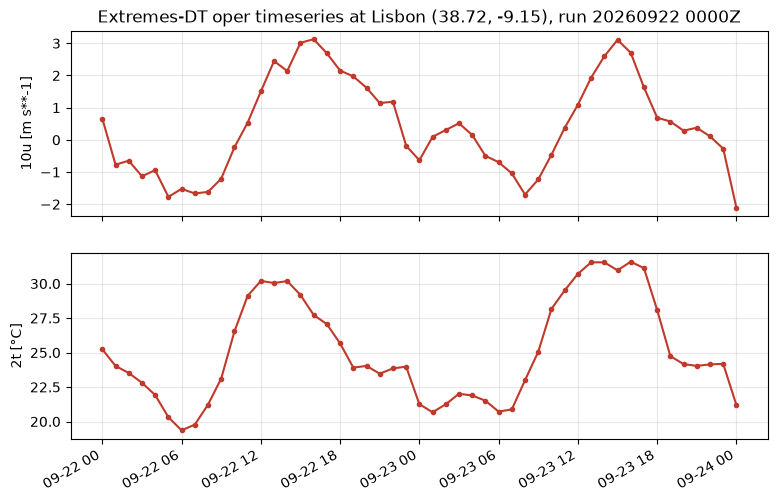

In [11]:
# Live request 1: the point time series (canonical shape, multi-param 10u + 2t).
name, reg = region()
ts_req = feature_request("timeseries", reg, event)
print(json.dumps(ts_req))
ts = fetch(ts_req, cache_name("timeseries", name, ts_req))
plot_feature("timeseries", ts, reg, name, ts_req)

2026-09-24 17:53:15 - INFO - Key read from /Users/mauf/.polytopeapirc


2026-09-24 17:53:15 - INFO - Sending request...
{'request': 'class: d1\n'
            'dataset: extremes-dt\n'
            "date: '-2'\n"
            "expver: '0001'\n"
            'feature:\n'
            '  axes:\n'
            '  - latitude\n'
            '  - longitude\n'
            '  shape:\n'
            '  - - 39.5\n'
            '    - -10.0\n'
            '  - - 39.5\n'
            '    - -8.5\n'
            '  - - 38.0\n'
            '    - -8.5\n'
            '  - - 38.0\n'
            '    - -10.0\n'
            '  - - 39.5\n'
            '    - -10.0\n'
            '  type: polygon\n'
            'levtype: sfc\n'
            'param: 165/167\n'
            "step: '12'\n"
            'stream: oper\n'
            "time: '0000'\n"
            'type: fc\n',
 'verb': 'retrieve'}


2026-09-24 17:53:15 - INFO - Polytope user key found in session cache for user mauf


polygon -> {"dataset": "extremes-dt", "class": "d1", "stream": "oper", "type": "fc", "date": "-2", "time": "0000", "levtype": "sfc", "expver": "0001", "param": "165/167", "step": "12", "feature": {"type": "polygon", "shape": [[39.5, -10.0], [39.5, -8.5], [38.0, -8.5], [38.0, -10.0], [39.5, -10.0]], "axes": ["latitude", "longitude"]}}


2026-09-24 17:53:15 - INFO - Request accepted. Please poll ./01ejwrk983830yp00bjc1hfsq9 for status


2026-09-24 17:53:15 - INFO - Polytope user key found in session cache for user mauf


2026-09-24 17:53:15 - INFO - Checking request status (01ejwrk983830yp00bjc1hfsq9)...


2026-09-24 17:53:16 - INFO - The current status of the request is 'processed'


01ejwrk983830yp00bjc1hfsq9.covjson:   0%|          | 0.00/83.0k [00:00<?, ?B/s]

  polytope answered in 1.9s -> cached output/uc07/polygon_Lisbon_m2_12.covjson
  {'datetimes': 1, 'number': 1, 'steps': 1, 'points': 1050} variables=['10u', '2t']


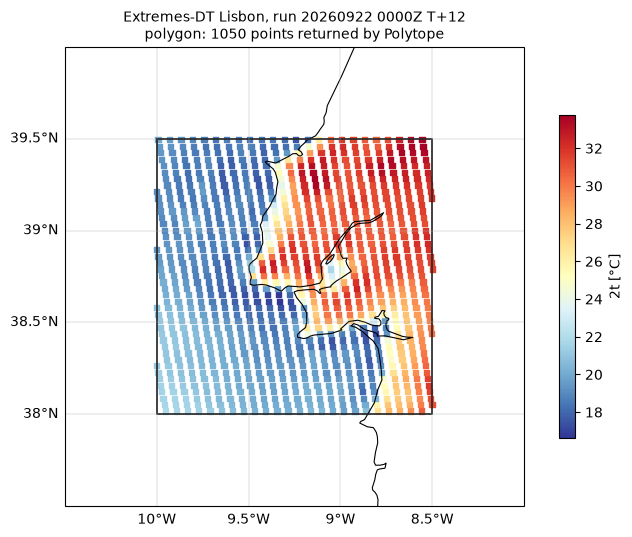

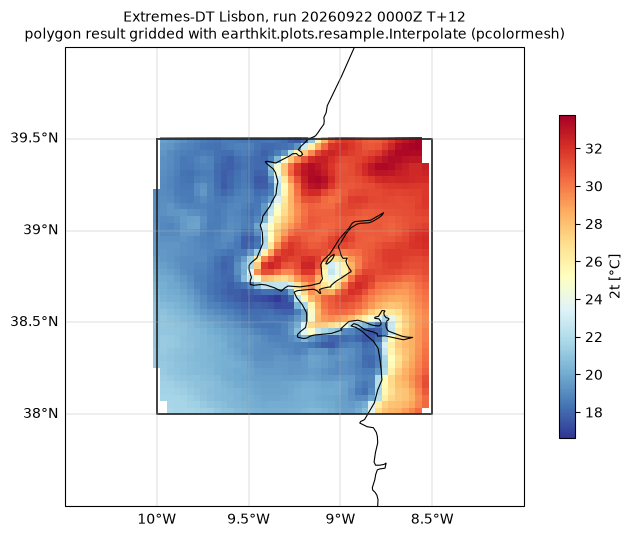

In [12]:
# Live request 2: the feature selected in the drop-down (default: polygon cut-out of the region).
kind = w_feature.value
sel_req = feature_request(kind, reg, event)
print(kind, "->", json.dumps(sel_req)[:400])
sel = fetch(sel_req, cache_name(kind, name, sel_req))
plot_feature(kind, sel, reg, name, sel_req)

## 6. The whole pipeline

`process_region_event(notification)` is what a live listener calls: read the region and the
menus, build the two Polytope requests from the notification (time series plus the selected
feature), fetch, plot. It runs here on the test notification received in section 4 (or on a
synthetic one if the publish was disabled), and `listen_and_process` shows the time-bounded
live loop that hands every matching notification to it.

2026-09-24 17:53:18 - INFO - Key read from /Users/mauf/.polytopeapirc


2026-09-24 17:53:18 - INFO - Sending request...
{'request': 'class: d1\n'
            'dataset: extremes-dt\n'
            "date: '-2'\n"
            "expver: '0001'\n"
            'feature:\n'
            '  axes: step\n'
            '  points:\n'
            '  - - 38.72\n'
            '    - -9.15\n'
            '  range:\n'
            '    end: 48\n'
            '    start: 0\n'
            '  type: timeseries\n'
            'levtype: sfc\n'
            'param: 165/167\n'
            'stream: oper\n'
            "time: '0000'\n"
            'type: fc\n',
 'verb': 'retrieve'}


2026-09-24 17:53:18 - INFO - Polytope user key found in session cache for user mauf


notification seq=26 roitest date=20260924 time=1552 -> region 'Lisbon', feature 'polygon'
timeseries request: {"dataset": "extremes-dt", "class": "d1", "stream": "oper", "type": "fc", "date": "-2", "time": "0000", "levtype": "sfc", "expver": "0001", "param": "165/167", "feature": {"type": "timeseries", "points": [[38.72, -9.15]], "axes": "step", "range": {"start": 0, "end": 48}}}


2026-09-24 17:53:18 - INFO - Request accepted. Please poll ./01ejwrk983830yw00bnvaxwp58 for status


2026-09-24 17:53:18 - INFO - Polytope user key found in session cache for user mauf


2026-09-24 17:53:18 - INFO - Checking request status (01ejwrk983830yw00bnvaxwp58)...


2026-09-24 17:53:19 - INFO - The current status of the request is 'processed'


01ejwrk983830yw00bnvaxwp58.covjson:   0%|          | 0.00/5.52k [00:00<?, ?B/s]

  polytope answered in 1.7s -> cached output/uc07/timeseries_Lisbon_m2_x.covjson
  {'latitude': 1, 'longitude': 1, 'levelist': 1, 'number': 1, 'datetime': 1, 't': 49} variables=['10u', '2t']


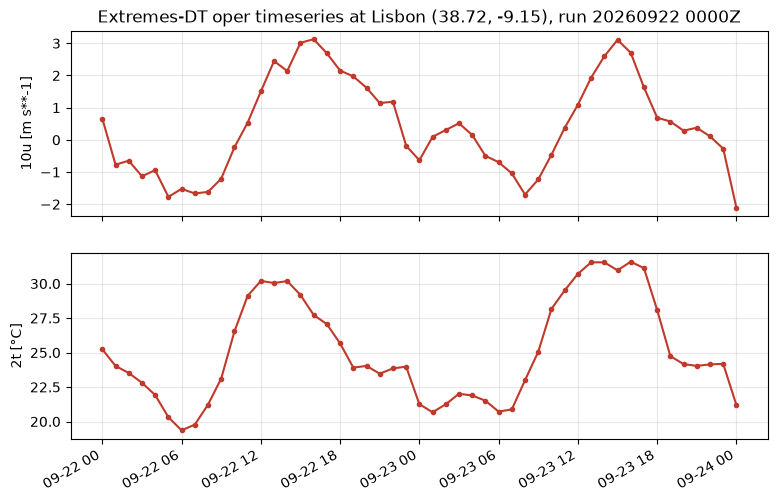

2026-09-24 17:53:20 - INFO - Key read from /Users/mauf/.polytopeapirc


2026-09-24 17:53:20 - INFO - Sending request...
{'request': 'class: d1\n'
            'dataset: extremes-dt\n'
            "date: '-2'\n"
            "expver: '0001'\n"
            'feature:\n'
            '  axes:\n'
            '  - latitude\n'
            '  - longitude\n'
            '  shape:\n'
            '  - - 39.5\n'
            '    - -10.0\n'
            '  - - 39.5\n'
            '    - -8.5\n'
            '  - - 38.0\n'
            '    - -8.5\n'
            '  - - 38.0\n'
            '    - -10.0\n'
            '  - - 39.5\n'
            '    - -10.0\n'
            '  type: polygon\n'
            'levtype: sfc\n'
            'param: 165/167\n'
            "step: '12'\n"
            'stream: oper\n'
            "time: '0000'\n"
            'type: fc\n',
 'verb': 'retrieve'}


2026-09-24 17:53:20 - INFO - Polytope user key found in session cache for user mauf


polygon request: {"dataset": "extremes-dt", "class": "d1", "stream": "oper", "type": "fc", "date": "-2", "time": "0000", "levtype": "sfc", "expver": "0001", "param": "165/167", "step": "12", "feature": {"type": "polygon", "shape": [[39.5, -10.0], [39.5, -8.5], [38.0, -8.5], [38.0, -10.0], [39.5, -10.0]], "axes": ["l


2026-09-24 17:53:20 - INFO - Request accepted. Please poll ./01ejwrk983830z000ba71w9q9q for status


2026-09-24 17:53:20 - INFO - Polytope user key found in session cache for user mauf


2026-09-24 17:53:20 - INFO - Checking request status (01ejwrk983830z000ba71w9q9q)...


2026-09-24 17:53:21 - INFO - The current status of the request is 'processed'


01ejwrk983830z000ba71w9q9q.covjson:   0%|          | 0.00/83.0k [00:00<?, ?B/s]

  polytope answered in 1.8s -> cached output/uc07/polygon_Lisbon_m2_12.covjson
  {'datetimes': 1, 'number': 1, 'steps': 1, 'points': 1050} variables=['10u', '2t']


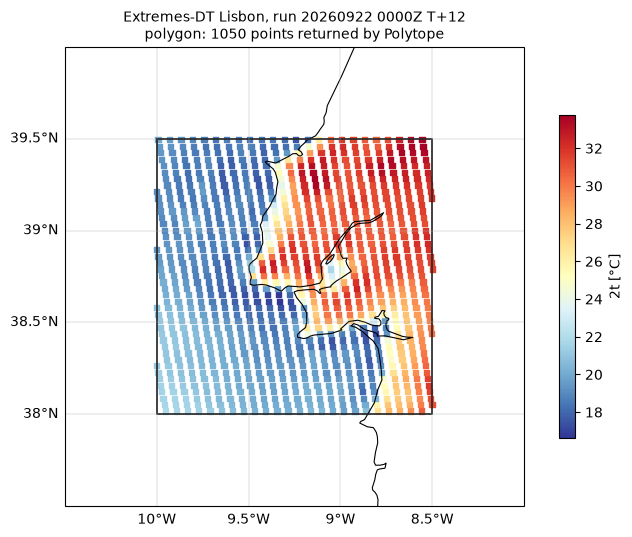

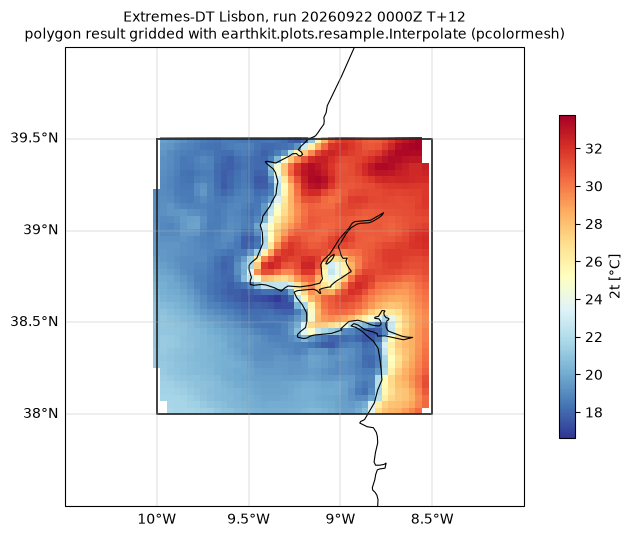

In [13]:
def process_region_event(notification):
    reg_name, reg = region()
    kind = w_feature.value
    print(f"notification seq={notification.sequence} {notification.identifier.get('experiment')} "
          f"date={notification.identifier.get('date')} time={notification.identifier.get('time')} -> region '{reg_name}', feature '{kind}'")
    for k in ("timeseries", kind) if kind != "timeseries" else ("timeseries",):
        req = feature_request(k, reg, notification)
        print(f"{k} request:", json.dumps(req)[:300])
        plot_feature(k, fetch(req, cache_name(k, reg_name, req)), reg, reg_name, req)


def listen_and_process(client, event_type, filter, *, seconds=60, max_events=1, handler=process_region_event):
    got = listen_many(client, event_type, {"roi": filter}, seconds=seconds)["roi"][:max_events]
    for n in got:
        handler(n)
    return got


RUN_PIPELINE_NOW = True
if RUN_PIPELINE_NOW:
    demo = event or pyaviso.Notification(POINTS_EVENT, 0, {"experiment": "synthetic", "date": date_for(), "time": "0000",
                                                           "point_cloud": point_cloud_for(reg)}, {"note": "synthetic"})
    process_region_event(demo)

# Live loop (waits up to 20 s here; raise `seconds` for a real session):
# listen_and_process(client, POINTS_EVENT, points_filter(reg), seconds=20)

## 7. On-demand Extremes-DT (DEODE) datacube

The **on-demand Extremes-DT** (DE_330 / DEODE) runs a limited-area model over a domain chosen
per run. Its output is a separate Polytope datacube: `dataset: "on-demand-extremes-dt"`,
`expver: "0099"`, and a **`georef`** key that identifies the run's domain (a geohash of the
domain centre). Feature extraction is enabled for that experiment only. The available
`georef`/date/param combinations are listed in the Destination Earth STAC catalogue:

<https://catalogue.lumi.apps.dte.destination-earth.eu/?class=d1&dataset=on-demand-extremes-dt&stream=oper&expver=0099&type=fc&date=2025-09-26&time=0000&georef=gcgkrb>

For a region-of-interest workflow this is the natural partner of an Aviso notification carrying
the `georef` (use case 4): the notification says which on-demand domain was produced, the
`georef` goes straight into the request. Shown as code only, no request is sent here.

In [14]:
# On-demand Extremes-DT: partial MARS request that identifies the datacube (from polytope-examples/on-demand-extremes-dt/README.md)
ON_DEMAND_CUBE = {
    "class": "d1",
    "dataset": "on-demand-extremes-dt",
    "stream": "oper",
    "expver": "0099",
    "type": "fc",
    "date": "2025-09-26",
    "time": "0000",
    "georef": "gcgkrb",          # the run's domain; take it from the notification or the STAC catalogue
}
STAC_URL = ("https://catalogue.lumi.apps.dte.destination-earth.eu/?class=d1&dataset=on-demand-extremes-dt"
            "&stream=oper&expver=0099&type=fc&date=2025-09-26&time=0000&georef=gcgkrb")

# Feature extraction on the on-demand cube: same shapes as section 5, plus `georef`
name, reg = region()
on_demand_timeseries = {
    **ON_DEMAND_CUBE, "date": "20250926", "levtype": "sfc", "param": "167",
    "feature": {"type": "timeseries", "points": [reg["point"]], "axes": "step", "range": {"start": 0, "end": 10}},
}
on_demand_full_field = {**ON_DEMAND_CUBE, "date": "20250926", "levtype": "sfc", "param": "167", "step": "12"}

print(json.dumps(on_demand_timeseries, indent=1))
print("\ncatalogue:", STAC_URL)
# data = ekd.from_source("polytope", "destination-earth", on_demand_timeseries, address=POLYTOPE_ADDRESS, stream=False)

{
 "class": "d1",
 "dataset": "on-demand-extremes-dt",
 "stream": "oper",
 "expver": "0099",
 "type": "fc",
 "date": "20250926",
 "time": "0000",
 "georef": "gcgkrb",
 "levtype": "sfc",
 "param": "167",
 "feature": {
  "type": "timeseries",
  "points": [
   [
    38.72,
    -9.15
   ]
  ],
  "axes": "step",
  "range": {
   "start": 0,
   "end": 10
  }
 }
}

catalogue: https://catalogue.lumi.apps.dte.destination-earth.eu/?class=d1&dataset=on-demand-extremes-dt&stream=oper&expver=0099&type=fc&date=2025-09-26&time=0000&georef=gcgkrb


## 8. Notes, quotas and related Polytope examples

**Aviso**

* **Formats differ per stream.** `de-scm-data-points` takes the polygon as a JSON list of
  `[lat, lon]`; `extreme_event` takes a string `"(lat,lon,...)"` or `point: "lat,lon"`. Both
  rings must be closed. Sending `point_cloud` in a filter is rejected.
* **Constraints are the numeric wildcard.** `severity: {"gte": 1}` matches every severity; string
  fields use `"*"`. Filter keys marked `required` must always be present.
* **Playground retention** is 10 days / 100k messages per stream. The test notification published
  here (`experiment=roitest`) is visible to everyone on the playground until then.
* **Production DestinE stream.** `data` on the LUMI Aviso 2 server has no spatial identifier. A
  region workflow there listens on the MARS-like keys (`class`, `stream`, `levtype`, `step`) and
  applies the region on the Polytope side, exactly as in section 5. Adding a `point_cloud` /
  `polygon` (or `georef`) identifier to that schema would let the server do the regional
  filtering as in section 4.

**Polytope**

* **Quota limits for DestinE:** up to **50 requests per second** (may be adjusted with system
  load) and at most **5 concurrent download requests**. An Aviso listener that fires one
  retrieval per notification stays far below the rate limit, but fan-out over many steps or
  regions should be queued to keep at most 5 downloads active.
* **LUMI vs MN5:** the same data is served from both data bridges. Switch the `address`
  argument of `earthkit.data.from_source` between `polytope.lumi.apps.dte.destination-earth.eu`
  and `polytope.mn5.apps.dte.destination-earth.eu`.
* **Feature extraction** on `extremes-dt` returned CoverageJSON for all six shapes above
  (`earthkit.data` 1.1: `.to_xarray()` works; `.to_pandas()` and `.to_target("file")` do not
  for CoverageJSON, hence the file copy in `fetch`). Polytope refuses forecast dates older than
  about two weeks (`Date is too old`).

**Related Polytope examples** (`~/Git/polytope/polytope-examples`, the request shapes used here)

* `extremes-dt/feature-extraction/extremes-dt-earthkit-example-fe-timeseries.ipynb`
* `extremes-dt/feature-extraction/extremes-dt-earthkit-example-fe-boundingbox.ipynb`
* `extremes-dt/feature-extraction/extremes-dt-earthkit-example-fe-polygon.ipynb`
* `extremes-dt/feature-extraction/extremes-dt-earthkit-example-fe-polygon-H3.ipynb`
* `extremes-dt/feature-extraction/extremes-dt-earthkit-example-fe-country.ipynb` (polygon `shape` from a country outline via `earthkit.geo.cartography.country_polygons`)
* `extremes-dt/feature-extraction/extremes-dt-earthkit-example-fe-pcolormesh.ipynb` (polygon result gridded with `earthkit.plots.resample.Interpolate`)
* `extremes-dt/feature-extraction/extremes-dt-earthkit-example-fe-verticalprofile.ipynb`
* `extremes-dt/feature-extraction/extremes-dt-earthkit-example-fe-trajectory.ipynb`, `...-fe-trajectory4d.ipynb`
* `extremes-dt/feature-extraction/extremes-dt-earthkit-example-fe-wave.ipynb`
* `on-demand-extremes-dt/feature-extraction/on-demand-extremes-dt-timeseries-fe-example.ipynb`, `on-demand-country-fe-example.ipynb`, `on-demand-trajectory-fe-example.ipynb`, `on-demand-extremes-dt-vertical-profile-fe-example.ipynb`
* `on-demand-extremes-dt/full-field/on-demand-extremes-dt-example.ipynb`
* Polytope documentation: <https://polytope.readthedocs.io/en/latest/Service/Full_fields/>

**In this repository:** `../aviso2-lumi-extremes-dt-earthkit.ipynb` (production stream,
full-field retrieval, email), `../../aviso-extreme-events.md` (spatial filters and constraints on
`extreme_event`), `../../DE/aviso-examples/aviso-extremes-dt-polytope-download.py`.